In [1]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

In [2]:
# Load the Iris dataset

iris = load_iris()

In [3]:
# Convert the dataset into a DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
# Keep only Petal Length and Petal Width

df = df[['petal length (cm)', 'petal width (cm)']]

df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


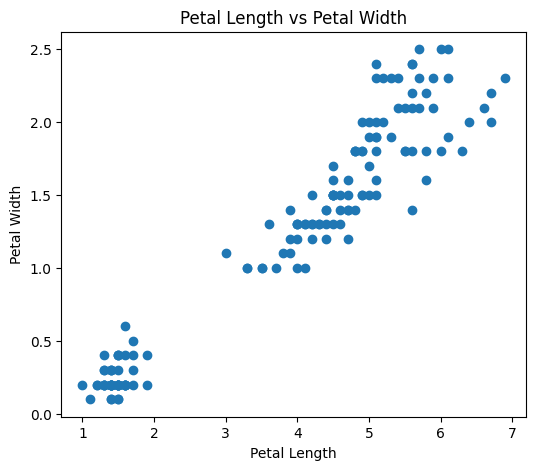

In [5]:
# Plot the data points

plt.figure(figsize=(6,5))

plt.scatter(df['petal length (cm)'],
            df['petal width (cm)'])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")

plt.show()

In [6]:
# Create the KMeans model

km = KMeans(n_clusters=3, random_state=42)

y_predicted = km.fit_predict(df)

y_predicted

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [7]:
# Add the cluster labels to the dataset

df['cluster'] = y_predicted

df.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1
3,1.5,0.2,1
4,1.4,0.2,1


In [8]:
# Display the cluster centers

km.cluster_centers_

array([[5.59583333, 2.0375    ],
       [1.462     , 0.246     ],
       [4.26923077, 1.34230769]])

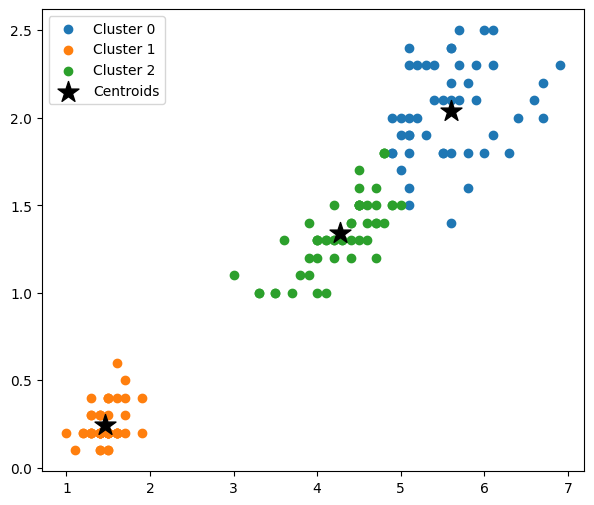

In [9]:
# Plot the clustered data

df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.figure(figsize=(7,6))

plt.scatter(df1['petal length (cm)'],
            df1['petal width (cm)'],
            label='Cluster 0')

plt.scatter(df2['petal length (cm)'],
            df2['petal width (cm)'],
            label='Cluster 1')

plt.scatter(df3['petal length (cm)'],
            df3['petal width (cm)'],
            label='Cluster 2')

plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            marker='*',
            s=250,
            color='black',
            label='Centroids')

plt.legend()

plt.show()

In [10]:
# Scale the Petal Length feature

scaler = MinMaxScaler()

df['petal length (cm)'] = scaler.fit_transform(
    df[['petal length (cm)']]
)

In [11]:
# Scale the Petal Width feature

df['petal width (cm)'] = scaler.fit_transform(
    df[['petal width (cm)']]
)

In [12]:
# Display the scaled dataset

df.head()

,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1


In [13]:
# Apply KMeans after scaling

km = KMeans(n_clusters=3, random_state=42)

df['cluster'] = km.fit_predict(
    df[['petal length (cm)', 'petal width (cm)']]
)

In [14]:
# Display the new cluster centers

km.cluster_centers_

array([[0.7740113 , 0.81510417],
       [0.07830508, 0.06083333],
       [0.55867014, 0.51041667]])

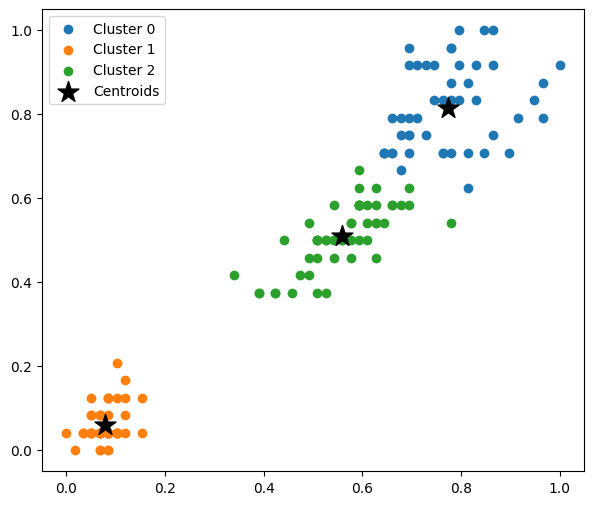

In [15]:
# Plot the scaled clustered data

df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.figure(figsize=(7,6))

plt.scatter(df1['petal length (cm)'],
            df1['petal width (cm)'],
            label='Cluster 0')

plt.scatter(df2['petal length (cm)'],
            df2['petal width (cm)'],
            label='Cluster 1')

plt.scatter(df3['petal length (cm)'],
            df3['petal width (cm)'],
            label='Cluster 2')

plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            marker='*',
            s=250,
            color='black',
            label='Centroids')

plt.legend()

plt.show()

In [16]:
# Create an empty list to store SSE values

sse = []

In [17]:
# Define the range of K values

k_rng = range(1,11)

In [18]:
# Calculate SSE for different values of K

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[['petal length (cm)', 'petal width (cm)']])
    sse.append(km.inertia_)

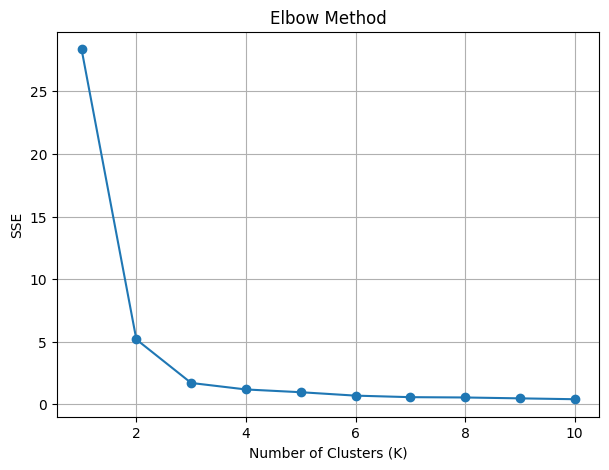

In [19]:
# Plot the Elbow Method graph

plt.figure(figsize=(7,5))

plt.plot(k_rng, sse, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method")

plt.grid(True)

plt.show()